In [7]:
import control as ctrl
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
def plant(B_val):
    num = [1]
    den = [1, B_val, 0]
    return ctrl.tf(num, den)

In [ ]:
G_B05 = plant(0.5)
G_B01 = plant(-0.1)

G_B05_closed = ctrl.feedback(G_B05, 1)
G_B01_closed = ctrl.feedback(G_B01, 1)

## PARTE A

### Inciso A

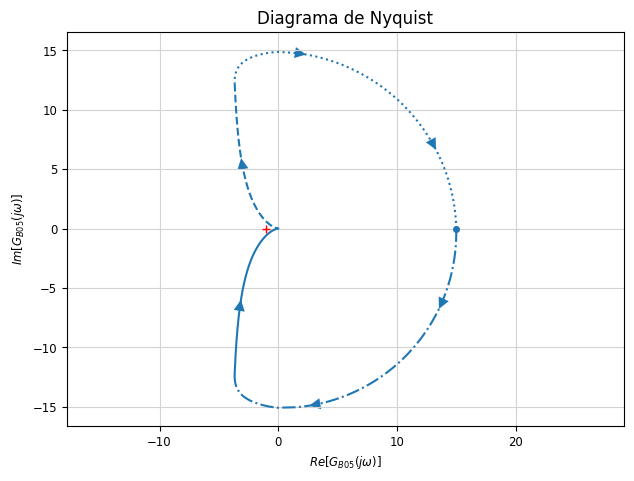

In [ ]:
plt.figure()
ctrl.nyquist_plot(G_B05, title='')
plt.title('Diagrama de Nyquist')
plt.xlabel('$Re[G_{B05}(j\\omega)]$')
plt.ylabel('$Im[G_{B05}(j\\omega)]$')
plt.grid(True)
plt.axis('equal')
plt.show()

##### A partir del criterio de estabilidad de Nyquist, se puede observar que el sistema es estable en lazo cerrado:
- $P = 0$ (cantidad de polos del sistema a lazo abierto que estan en el RHP)
- $N = 0$ (cantidad de vueltas alrededor de $-1+j0$)
- $Z = P - N$ donde $Z$ es la cantidad de polos del sistema a lazo cerrado en el RHP, el cual es $Z = 0$

### Inciso B

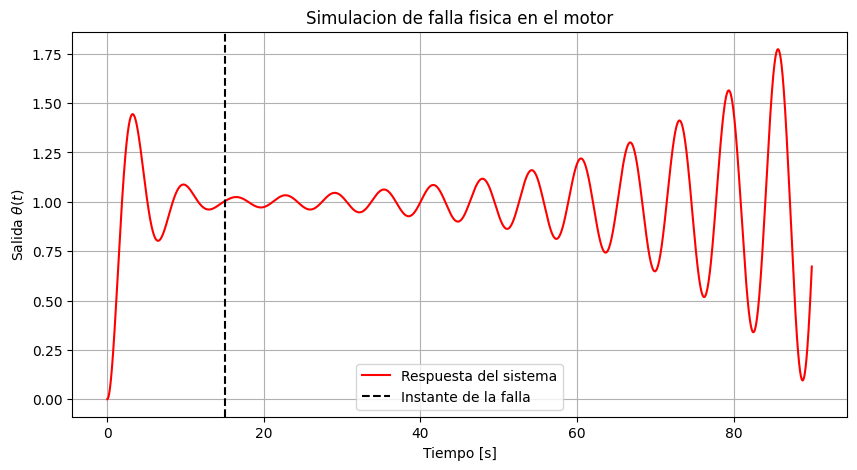

In [14]:
# Tiempos de simulacion
t1 = np.linspace(0, 15, 1000)
t2 = np.linspace(15, 90, 3000)

# Sistema con B=0.5
sys1 = ctrl.ss(G_B05_closed)
response1 = ctrl.forced_response(sys1, T=t1, U=1)
t_out1 = response1.time
y_out1 = response1.outputs
x_out1 = response1.states
x_final_stage1 = x_out1[:, -1]

# Sistema con B=-0.1
sys2 = ctrl.ss(G_B01_closed)
response2 = ctrl.forced_response(sys2, T=t2, U=1, X0=x_final_stage1)
t_out2 = response2.time
y_out2 = response2.outputs
x_out2 = response2.states

t_total = np.concatenate([t_out1, t_out2])
y_total = np.concatenate([y_out1, y_out2])

plt.figure(figsize=(10, 5))
plt.plot(t_total, y_total, label='Respuesta del sistema', color='red')
plt.axvline(x=15, color='black', linestyle='--', label='Instante de la falla')
plt.xlabel('Tiempo [s]')
plt.ylabel('Salida $\\theta(t)$')
plt.title('Simulacion de falla fisica en el motor')
plt.grid(True)
plt.legend()
plt.show()

### Inciso C

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


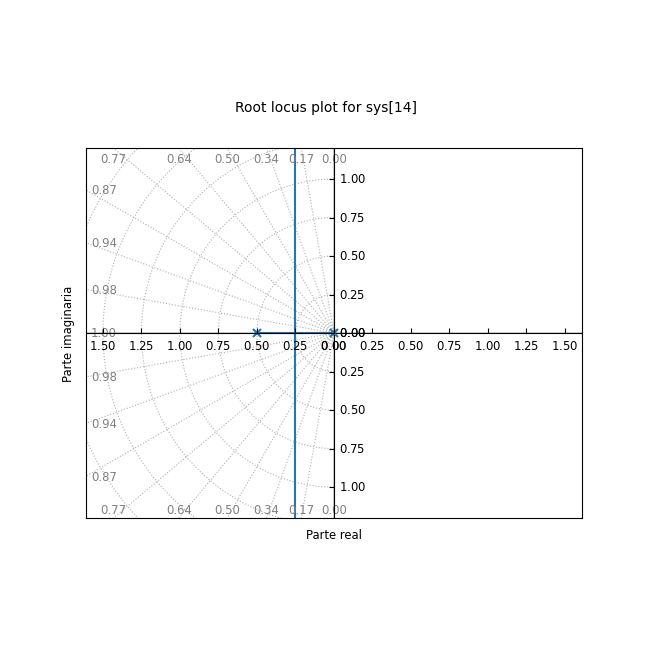

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


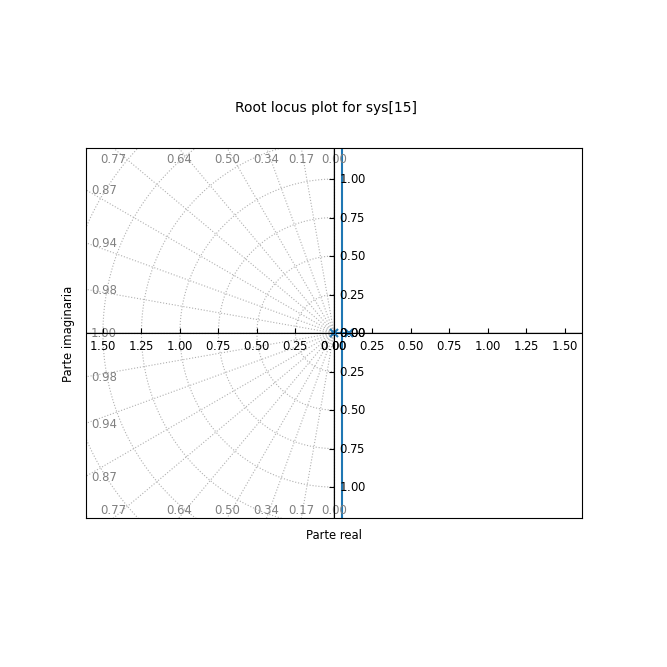

In [18]:
ctrl.root_locus(G_B05)
plt.xlabel('Parte real')
plt.ylabel('Parte imaginaria')
plt.xlim(-1.2, 1.2) 
plt.ylim(-1.2, 1.2)
plt.grid(True)
plt.show()

ctrl.root_locus(G_B01)
plt.xlabel('Parte real')
plt.ylabel('Parte imaginaria')
plt.xlim(-1.2, 1.2) 
plt.ylim(-1.2, 1.2)
plt.grid(True)
plt.show()

##### La estabilidad depende del valor de B: la función de transferencia es $\tfrac{K}{s(Js+B)}=\tfrac{1}{s(s+B)}$, los polos del sistema son $s=0$ y $s=-B$
##### De esta manera:
- Con $B>0$ el polo tiene parte real negativa, por lo que el sistema es estable.
- Con $B<0$ el polo tiene parte real positiva, por lo que el sistema es inestable.
- Con $B=0$ hay doble polo en cero, po rlo que el sistema se vuelve marginalmente estable (oscila).

##### En cuanto a la robustez, frente a un cambio pequeño que cruce el eje imaginario destruye el control del sistema. Además, incluso si $B$ se mantiene positivo, el sistema es sensible (si $B$ disminuye aparecen oscilaciones o sobrepicos y si aumenta mucho el sistema se vuelve muy lento)

### Inciso D

##### A partir de los resultados anteriores, el tipo de compensador que se considera adecuado es un compensador en adelanto. Esta elección se debe a que el sistema tiene un polo en el origen ($s=0$) que aporta -90° de fase, y un segundo polo en $s=-B$ el cual aporta de manera distinta a la fase:
- B>0: polo estable, la fase total tiende a -180° pero no la alcanza.
- B=0: polo doble en el origen, con fase constante de -180°, lo que hace que el sistema sea marginalmente estable (oscila).
- B<0: la fase cae por debajo de los -180°, por lo que convierte al sistema en inestable.
##### De esta manera, el compensador en adelanto agregaria fase positiva al sistema en lazo abierto, incrementando el margen de fase, permitiendo que el sistema soporte la falla.

## <span style='color:red'>Parte B</span>

#### <span style='color:red'>Inciso A</span>

#### <span style='color:red'>Inciso B</span>

#### <span style='color:red'>Inciso C</span>

#### <span style='color:red'>Inciso D</span>